SISTEMA EXPERTO

In [29]:
!pip install networkx==2.8.8
!pip install scikit-fuzzy

In [30]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import csv
import matplotlib.pyplot as plt

In [31]:
edad = ctrl.Antecedent(np.arange(18, 100, 1), 'edad')
cantidad_trabajo_pantalla = ctrl.Antecedent(np.arange(0, 20, 1), 'cantidad_trabajo_pantalla')
carga_total = ctrl.Antecedent(np.arange(1, 11, 1), 'carga_total')
sueno = ctrl.Antecedent(np.arange(1, 11, 1), 'sueno')
tiempo_pantalla_estudio = ctrl.Antecedent(np.arange(0, 15, 1), 'tiempo_pantalla_estudio')
tiempo_pantalla_ocio = ctrl.Antecedent(np.arange(0, 15, 1), 'tiempo_pantalla_ocio')
apoyo = ctrl.Antecedent(np.arange(1, 11, 1), 'apoyo')
pausas = ctrl.Antecedent(np.arange(0, 6, 1), 'pausas')
agotamiento = ctrl.Antecedent(np.arange(1, 11, 1), 'agotamiento')
energia = ctrl.Antecedent(np.arange(1, 11, 1), 'energia')
agotamiento_emocional = ctrl.Antecedent(np.arange(1, 11, 1), 'agotamiento_emocional')
eficacia_personal = ctrl.Antecedent(np.arange(1, 11, 1), 'eficacia_personal')
dificultad_desconectar =  ctrl.Antecedent(np.arange(1, 11, 1), 'desconectar')
presion_digital = ctrl.Antecedent(np.arange(1, 11, 1), 'presion_digital')

burnout = ctrl.Consequent(np.arange(0, 11, 1), 'burnout')



In [32]:
edad['joven'] = fuzz.trimf(edad.universe, [18, 18, 25])
edad['profesional'] = fuzz.trimf(edad.universe, [25, 30, 38])
edad['senior'] = fuzz.trapmf(edad.universe, [35, 45, 80, 80])

cantidad_trabajo_pantalla['baja'] = fuzz.trapmf(cantidad_trabajo_pantalla.universe, [0, 0, 2, 5])
cantidad_trabajo_pantalla['media'] = fuzz.trimf(cantidad_trabajo_pantalla.universe, [3, 7,11])
cantidad_trabajo_pantalla['alta'] = fuzz.trapmf(cantidad_trabajo_pantalla.universe, [9, 12, 19, 19])

carga_total['ligera'] = fuzz.trapmf(carga_total.universe, [1, 1, 2, 4])
carga_total['manejable'] = fuzz.trimf(carga_total.universe, [3, 5, 7])
carga_total['abrumadora'] = fuzz.trapmf(carga_total.universe, [6, 8, 10, 10])


sueno['insuficiente'] = fuzz.trapmf(sueno.universe, [1, 1, 2, 4])
sueno['pobre'] = fuzz.trimf(sueno.universe, [3, 4, 6])
sueno['aceptable'] = fuzz.trimf(sueno.universe, [5, 6, 8])
sueno['fantastica'] = fuzz.trapmf(sueno.universe, [7, 8, 10, 10])


tiempo_pantalla_estudio['escaso'] = fuzz.trapmf(tiempo_pantalla_estudio.universe, [0, 0, 1, 2])
tiempo_pantalla_estudio['medio'] = fuzz.trimf(tiempo_pantalla_estudio.universe, [1, 2, 4])
tiempo_pantalla_estudio['alto'] = fuzz.trimf(tiempo_pantalla_estudio.universe, [3, 5, 8])
tiempo_pantalla_estudio['excesivo'] = fuzz.trapmf(tiempo_pantalla_estudio.universe, [6, 8, 14, 14])

tiempo_pantalla_ocio['escaso'] = fuzz.trapmf(tiempo_pantalla_ocio.universe, [0, 0, 1, 2])
tiempo_pantalla_ocio['medio'] = fuzz.trimf(tiempo_pantalla_ocio.universe, [1, 2, 4])
tiempo_pantalla_ocio['alto'] = fuzz.trimf(tiempo_pantalla_ocio.universe, [3, 5, 8])
tiempo_pantalla_ocio['excesivo'] = fuzz.trapmf(tiempo_pantalla_ocio.universe, [6, 8, 14, 14])

apoyo['poco'] = fuzz.trapmf(apoyo.universe, [1, 1, 2, 4])
apoyo['neutro'] = fuzz.trimf(apoyo.universe, [3, 5, 7])
apoyo['mucho'] = fuzz.trapmf(apoyo.universe, [6, 8, 10, 10])

pausas['ninguna'] = fuzz.trimf(pausas.universe, [0, 0, 1])
pausas['minimo'] = fuzz.trimf(pausas.universe, [0, 2, 3])
pausas['bastantes'] = fuzz.trapmf(pausas.universe, [2, 3, 5, 5])

agotamiento['infimo'] = fuzz.trapmf(agotamiento.universe, [1, 1, 2, 4])
agotamiento['ordinario'] = fuzz.trimf(agotamiento.universe, [3, 5, 7])
agotamiento['elevado'] = fuzz.trapmf(agotamiento.universe, [6, 8, 10, 10])

energia['facil'] = fuzz.trapmf(energia.universe, [1, 1, 2, 4])
energia['normal'] = fuzz.trimf(energia.universe, [3, 5, 7])
energia['dificil'] = fuzz.trapmf(energia.universe, [6, 8, 10, 10])

agotamiento_emocional['escaso'] = fuzz.trapmf(agotamiento_emocional.universe, [1, 1, 2, 4])
agotamiento_emocional['esporadico'] = fuzz.trimf(agotamiento_emocional.universe, [3, 5, 7])
agotamiento_emocional['frecuente'] = fuzz.trapmf(agotamiento_emocional.universe, [6, 8, 10, 10])

eficacia_personal['baja'] = fuzz.trapmf(eficacia_personal.universe, [1, 1, 2, 4])
eficacia_personal['moderada'] = fuzz.trimf(eficacia_personal.universe, [3, 5, 7])
eficacia_personal['alta'] = fuzz.trimf(eficacia_personal.universe, [5, 7, 9])
eficacia_personal['muy_alta'] = fuzz.trapmf(eficacia_personal.universe, [7, 9, 10, 10])

dificultad_desconectar['baja'] = fuzz.trapmf(dificultad_desconectar.universe, [1, 1, 2, 4])
dificultad_desconectar['moderada'] = fuzz.trimf(dificultad_desconectar.universe, [3, 5, 7])
dificultad_desconectar['alta'] = fuzz.trapmf(dificultad_desconectar.universe, [6, 8, 10, 10])

presion_digital['raramente'] = fuzz.trapmf(presion_digital.universe, [1, 1, 2, 4])
presion_digital['ocasionalmente'] = fuzz.trimf(presion_digital.universe, [3, 5, 7])
presion_digital['constantemente'] = fuzz.trapmf(presion_digital.universe, [6, 8, 10, 10])

burnout['bajo'] = fuzz.trapmf(burnout.universe, [0, 0, 1, 3])
burnout['moderado'] = fuzz.trimf(burnout.universe, [2, 4, 6])
burnout['alto'] = fuzz.trimf(burnout.universe, [5, 7, 9])
burnout['critico'] = fuzz.trapmf(burnout.universe, [7, 9, 10, 10])


**viusalización de las variables**

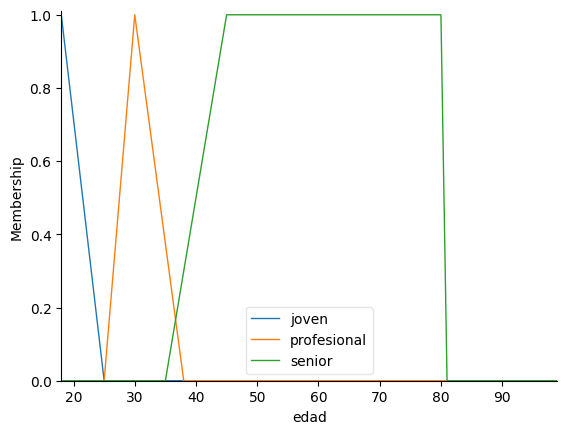

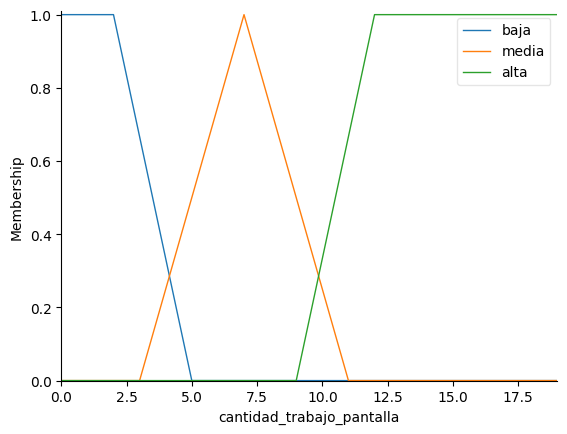

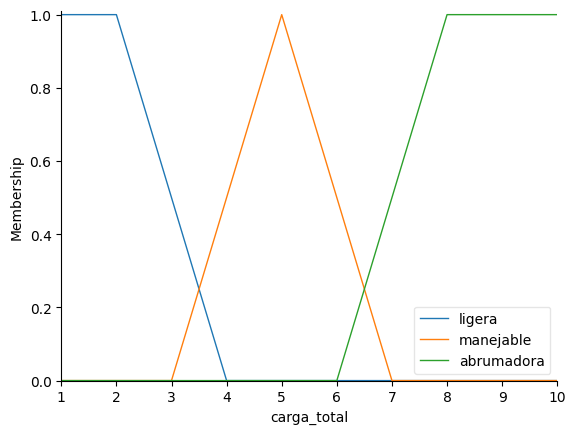

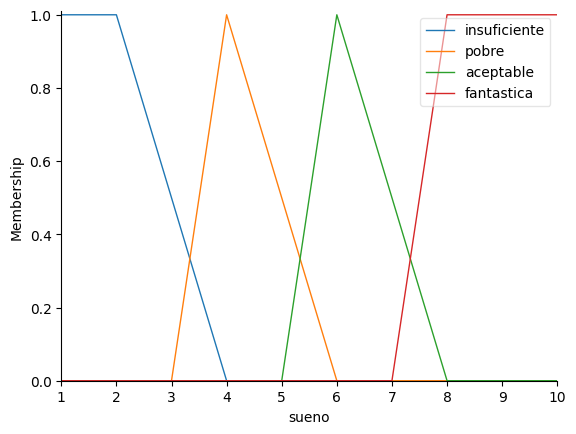

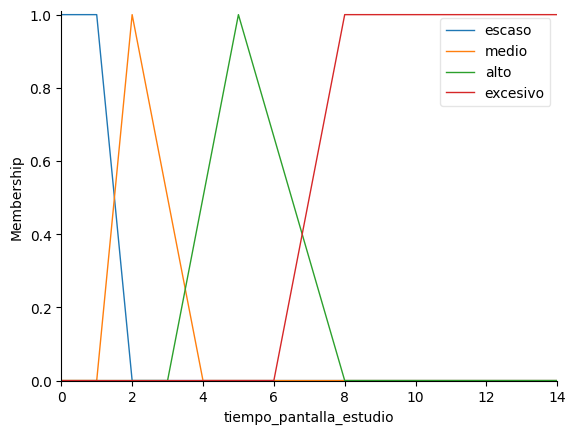

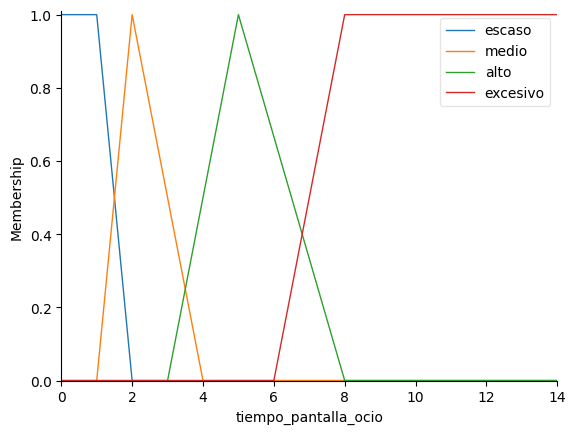

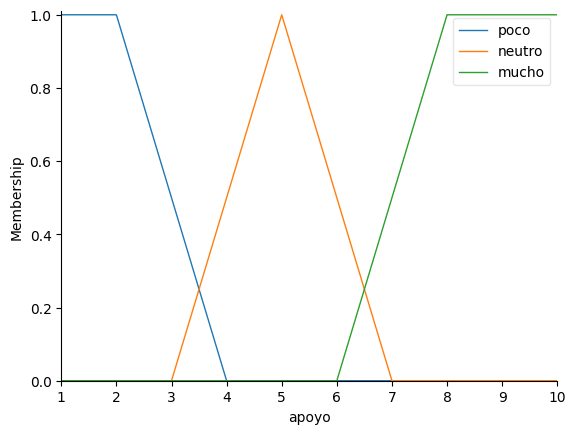

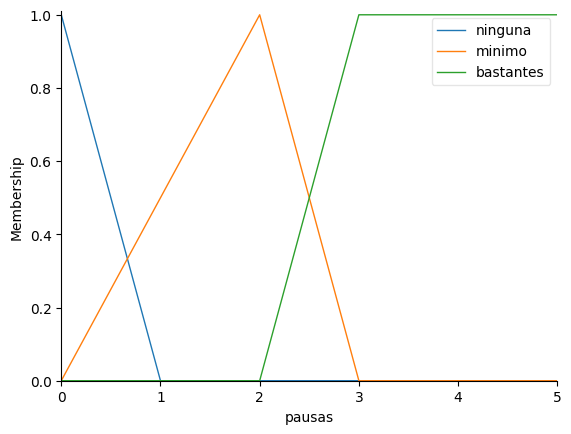

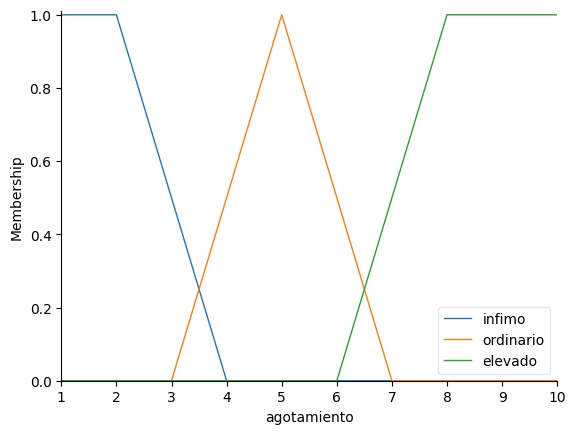

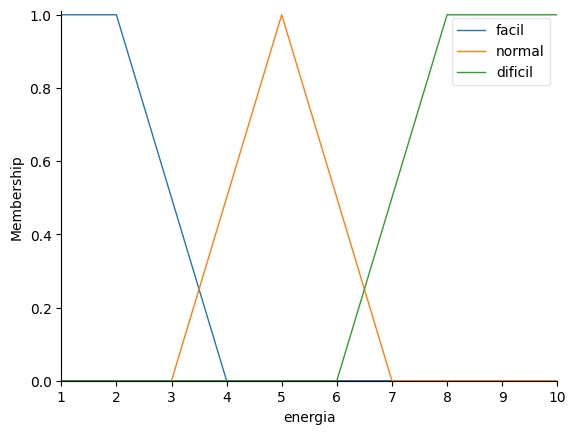

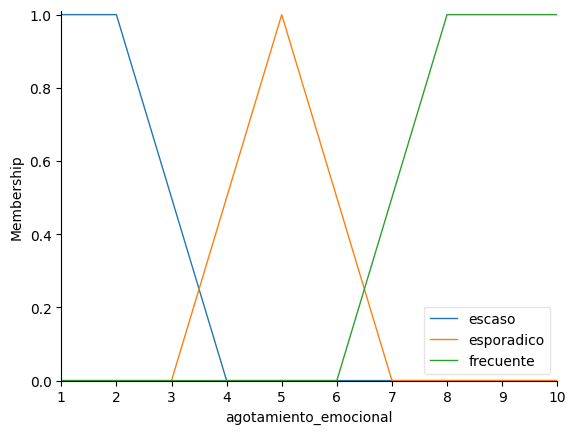

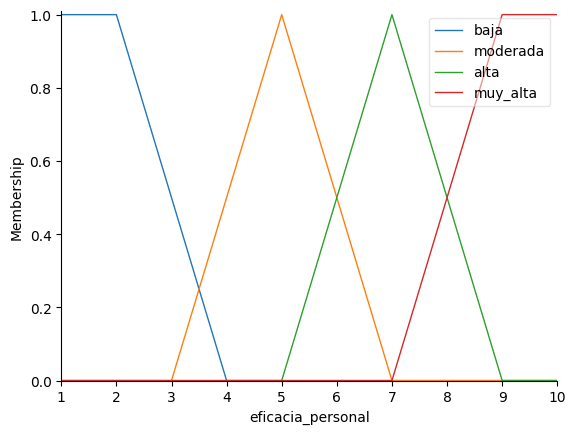

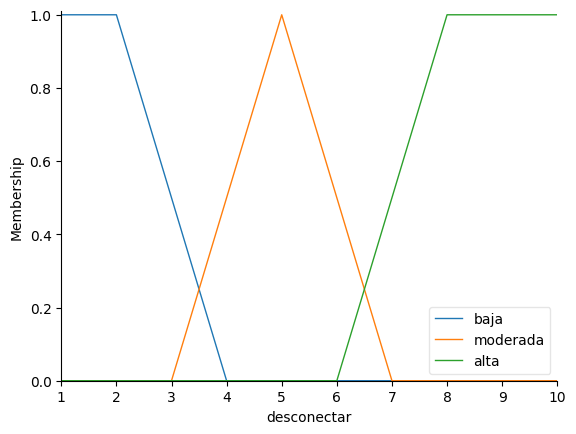

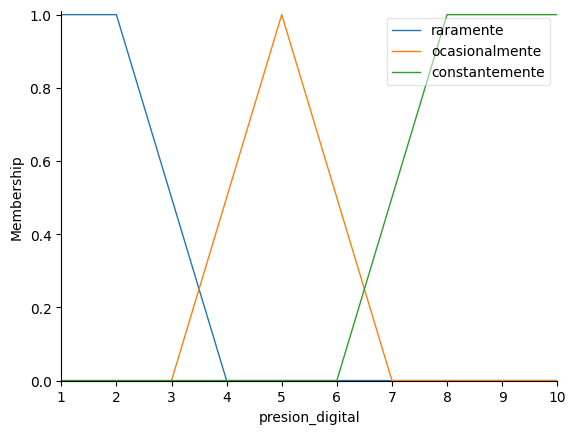

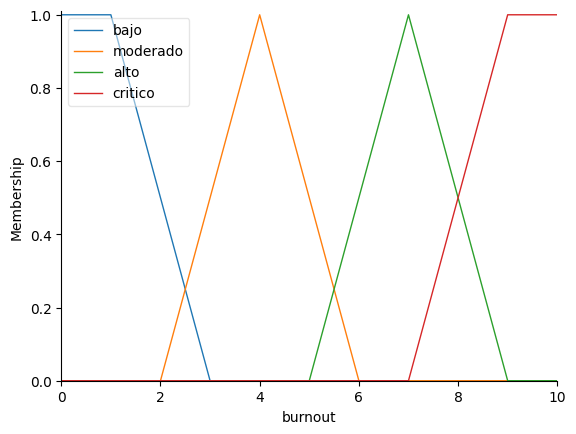

In [33]:
edad.view()
cantidad_trabajo_pantalla.view()
carga_total.view()
sueno.view()
tiempo_pantalla_estudio.view()
tiempo_pantalla_ocio.view()
apoyo.view()
pausas.view()
agotamiento.view()
energia.view()
agotamiento_emocional.view()
eficacia_personal.view()
dificultad_desconectar.view()
presion_digital.view()
burnout.view()

 **definición de reglas**

In [34]:
# --------ruleS BURNOUT CRÍTICO--------

# rule1: Agotamiento elevado, emocional frecuente y baja eficacia personal indican colapso total.
rule1 = ctrl.Rule(
    agotamiento['elevado'] & agotamiento_emocional['frecuente'] & eficacia_personal['baja'],
    burnout['critico']
)

# rule2: Carga abrumadora con falta de sueño y poco apoyo social es una combinación de riesgo extremo.
rule2 = ctrl.Rule(
    carga_total['abrumadora'] & sueno['insuficiente'] & apoyo['poco'],
    burnout['critico']
)

# rule3: El agotamiento elevado sumado a la incapacidad de desconectar y presión digital constante.
rule3 = ctrl.Rule(
    agotamiento['elevado'] & dificultad_desconectar['alta'] & presion_digital['constantemente'],
    burnout['critico']
)

# rule4: Dificultad extrema para recuperar energía con agotamiento emocional y falta de sueño.
rule4 = ctrl.Rule(
    energia['dificil'] & agotamiento_emocional['frecuente'] & sueno['insuficiente'],
    burnout['critico']
)

# rule5: Jornadas largas de pantalla sin pausas y con agotamiento ya elevado.
rule5 = ctrl.Rule(
    cantidad_trabajo_pantalla['alta'] & pausas['ninguna'] & agotamiento['elevado'],
    burnout['critico']
)

# rule6: Carga de trabajo excesiva que agota al usuario y anula su sensación de eficacia.
rule6 = ctrl.Rule(
    carga_total['abrumadora'] & agotamiento['elevado'] & eficacia_personal['baja'],
    burnout['critico']
)

# rule7: El exceso de pantalla tanto en estudio como en ocio sumado a no dormir nada.
rule7 = ctrl.Rule(
    tiempo_pantalla_estudio['excesivo'] & tiempo_pantalla_ocio['excesivo'] & sueno['insuficiente'],
    burnout['critico']
)

# rule8: Agotamiento elevado por el uso abusivo de pantallas en todos los ámbitos de la vida.
rule8 = ctrl.Rule(
    agotamiento['elevado'] & tiempo_pantalla_estudio['excesivo'] & tiempo_pantalla_ocio['excesivo'],
    burnout['critico']
)

# rule9: Alta carga de trabajo digital sumada a exceso de pantalla en tiempo libre y estudio.
rule9 = ctrl.Rule(
    cantidad_trabajo_pantalla['alta'] & tiempo_pantalla_estudio['excesivo'] & tiempo_pantalla_ocio['excesivo'],
    burnout['critico']
)

# rule10: Presión digital externa constante unida a una exposición total a las pantallas.
rule10 = ctrl.Rule(
    presion_digital['constantemente'] & tiempo_pantalla_estudio['excesivo'] & tiempo_pantalla_ocio['excesivo'],
    burnout['critico']
)

# rule11: Imposibilidad de recuperar energía tras una exposición masiva a pantallas de estudio y ocio.
rule11 = ctrl.Rule(
    energia['dificil'] & tiempo_pantalla_estudio['excesivo'] & tiempo_pantalla_ocio['excesivo'],
    burnout['critico']
)

# rule12: Falta de energía por exceso de trabajo laboral y tiempo excesivo de ocio digital.
rule12 = ctrl.Rule(
    energia['dificil'] & cantidad_trabajo_pantalla['alta'] & tiempo_pantalla_ocio['excesivo'],
    burnout['critico']
)

# rule13: La alta carga de trabajo y el estudio digital intensivo agotan la energía vital.
rule13 = ctrl.Rule(
    energia['dificil'] & cantidad_trabajo_pantalla['alta'] & tiempo_pantalla_estudio['excesivo'],
    burnout['critico']
)

# rule14: Presión externa constante y exceso de trabajo y ocio frente a la pantalla de forma simultánea.
rule14 = ctrl.Rule(
    presion_digital['constantemente'] & cantidad_trabajo_pantalla['alta'] & tiempo_pantalla_ocio['excesivo'],
    burnout['critico']
)

# rule15: El flujo constante de trabajo digital y estudio excesivo generan una presión psicológica crítica.
rule15 = ctrl.Rule(
    presion_digital['constantemente'] & cantidad_trabajo_pantalla['alta'] & tiempo_pantalla_estudio['excesivo'],
    burnout['critico']
)

# --------ruleS BURNOUT ALTO--------

# rule16: El agotamiento elevado se vuelve peligroso cuando el sueño ya es de mala calidad.
rule16 = ctrl.Rule(
    agotamiento['elevado'] & sueno['pobre'],
    burnout['alto']
)

# rule17: Agotamiento elevado sin un sistema de apoyo social sólido que amortigüe el estrés.
rule17 = ctrl.Rule(
    agotamiento['elevado'] & apoyo['neutro'],
    burnout['alto']
)

# rule18: Estar muy agotado y no realizar apenas descansos activos durante la jornada.
rule18 = ctrl.Rule(
    agotamiento['elevado'] & pausas['minimo'],
    burnout['alto']
)

# rule19: Carga abrumadora con poco apoyo emocional y calidad de sueño deficiente.
rule19 = ctrl.Rule(
    carga_total['abrumadora'] & apoyo['neutro'] & sueno['pobre'],
    burnout['alto']
)

# rule20: Desgaste emocional frecuente con eficacia apenas moderada y descanso insuficiente.
rule20 = ctrl.Rule(
    agotamiento_emocional['frecuente'] & eficacia_personal['moderada'] & sueno['pobre'],
    burnout['alto']
)

# rule21: Estudiar demasiadas horas en formato digital sin realizar ninguna pausa reparadora.
rule21 = ctrl.Rule(
    tiempo_pantalla_estudio['excesivo'] & pausas['ninguna'],
    burnout['alto']
)

# rule22: Incapacidad de desconectar sumada a la presión constante de las notificaciones digitales.
rule22 = ctrl.Rule(
    dificultad_desconectar['alta'] & presion_digital['constantemente'],
    burnout['alto']
)

# rule23: Dificultad para recuperar energía incluso cuando la carga de trabajo parece manejable.
rule23 = ctrl.Rule(
    energia['dificil'] & carga_total['manejable'],
    burnout['alto']
)

# rule24: Agotamiento elevado que no se compensa con el apoyo social o la eficacia percibida.
rule24 = ctrl.Rule(
    agotamiento['elevado'] & eficacia_personal['moderada'] & apoyo['neutro'],
    burnout['alto']
)

# rule25: El ocio digital nocturno o excesivo afecta gravemente la energía y el descanso posterior.
rule25 = ctrl.Rule(
    tiempo_pantalla_ocio['excesivo'] & sueno['pobre'] & energia['dificil'],
    burnout['alto']
)

# rule26: Fatiga crónica con sueño pobre a pesar de que el trabajo no es objetivamente excesivo.
rule26 = ctrl.Rule(
    energia['dificil'] & carga_total['manejable'] & sueno['pobre'],
    burnout['alto']
)

# rule27: Desgaste emocional frecuente con una baja sensación de logro o eficacia personal.
rule27 = ctrl.Rule(
    agotamiento_emocional['frecuente'] & eficacia_personal['moderada'] & apoyo['neutro'],
    burnout['alto']
)

# rule28: Imposibilidad de separar el trabajo digital tras una jornada intensa de ocio y presión externa.
rule28 = ctrl.Rule(
    dificultad_desconectar['alta'] & presion_digital['constantemente'] & tiempo_pantalla_ocio['alto'],
    burnout['alto']
)

# --------ruleS BURNOUT MODERADO--------

# rule29: Agotamiento ordinario que se mantiene bajo control gracias a un sueño aceptable.
rule29 = ctrl.Rule(
    agotamiento['ordinario'] & sueno['aceptable'],
    burnout['moderado']
)

# rule30: Episodios de agotamiento emocional que se compensan con una alta sensación de eficacia.
rule30 = ctrl.Rule(
    agotamiento_emocional['esporadico'] & eficacia_personal['alta'],
    burnout['moderado']
)

# rule31: Carga de trabajo manejable pero con un apoyo social que no es del todo suficiente.
rule31 = ctrl.Rule(
    carga_total['manejable'] & apoyo['neutro'],
    burnout['moderado']
)

# rule32: Uso alto de pantallas para estudio que se intenta paliar con descansos mínimos o insuficientes.
rule32 = ctrl.Rule(
    tiempo_pantalla_estudio['alto'] & pausas['minimo'],
    burnout['moderado']
)

# rule33: Dificultad moderada para desconectar bajo una presión digital que solo es ocasional.
rule33 = ctrl.Rule(
    dificultad_desconectar['moderada'] & presion_digital['ocasionalmente'],
    burnout['moderado']
)

# rule34: Energía en niveles normales pero mermada ocasionalmente por un descanso pobre.
rule34 = ctrl.Rule(
    energia['normal'] & sueno['pobre'],
    burnout['moderado']
)

# rule35: Agotamiento rutinario combinado con una dificultad media para separar el entorno digital de la vida privada.
rule35 = ctrl.Rule(
    agotamiento['ordinario'] & dificultad_desconectar['moderada'],
    burnout['moderado']
)


# --------ruleS BURNOUT BAJO--------

# rule36: Niveles de agotamiento ínfimos acompañados de un descanso nocturno fantástico.
rule36 = ctrl.Rule(
    agotamiento['infimo'] & sueno['fantastica'],
    burnout['bajo']
)

# rule37: Carga de trabajo ligera y un fuerte sistema de apoyo social y familiar.
rule37 = ctrl.Rule(
    carga_total['ligera'] & apoyo['mucho'],
    burnout['bajo']
)

# rule38: Sentirse muy capaz y productivo con muy poco o nulo desgaste emocional.
rule38 = ctrl.Rule(
    eficacia_personal['muy_alta'] & agotamiento_emocional['escaso'],
    burnout['bajo']
)

# rule39: Realizar pausas frecuentes y recibir muy poca presión digital del entorno.
rule39 = ctrl.Rule(
    pausas['bastantes'] & presion_digital['raramente'],
    burnout['bajo']
)

# rule40: Sueño reparador, mucho apoyo y gran facilidad para desconectar del mundo digital.
rule40 = ctrl.Rule(
    sueno['fantastica'] & apoyo['mucho'] & dificultad_desconectar['baja'],
    burnout['bajo']
)

# rule41: Agotamiento casi nulo, alta eficacia y gran facilidad para recuperar energías rápidamente.
rule41 = ctrl.Rule(
    agotamiento['infimo'] & eficacia_personal['alta'] & energia['facil'],
    burnout['bajo']
)

# --------ruleS CON EDAD--------

# rule42: Los jóvenes con carga abrumadora y poco sueño tienen un riesgo elevado de agotamiento temprano.
rule42 = ctrl.Rule(
    edad['joven'] & carga_total['abrumadora'] & sueno['pobre'],
    burnout['alto']
)

# rule43: Perfiles senior con agotamiento elevado y mucha dificultad para recuperar energía entran en zona crítica.
rule43 = ctrl.Rule(
    edad['senior'] & agotamiento['elevado'] & energia['dificil'],
    burnout['critico']
)

# rule44: Jóvenes que abusan del ocio digital y tienen alta dificultad para desconectar sufren desgaste alto.
rule44 = ctrl.Rule(
    edad['joven'] & tiempo_pantalla_ocio['excesivo'] & dificultad_desconectar['alta'],
    burnout['alto']
)


# --------ruleS BURNOUT CRÍTICO (adicionales)--------

# rule45: Carga abrumadora sin realizar pausas y con sueño insuficiente lleva al colapso del sistema.
rule45 = ctrl.Rule(
    carga_total['abrumadora'] & pausas['ninguna'] & sueno['insuficiente'],
    burnout['critico']
)

# rule46: Agotamiento emocional frecuente sin apoyo social y con gran dificultad para desconectar.
rule46 = ctrl.Rule(
    agotamiento_emocional['frecuente'] & apoyo['poco'] & dificultad_desconectar['alta'],
    burnout['critico']
)

# rule47: El profesional en activo con alta carga, agotamiento elevado y sin red de apoyo está en riesgo máximo.
rule47 = ctrl.Rule(
    edad['profesional'] & carga_total['abrumadora'] & agotamiento['elevado'] & apoyo['poco'],
    burnout['critico']
)

# rule48: Exceso de horas de pantalla laboral, sueño insuficiente y fatiga crónica que impide recuperar energía.
rule48 = ctrl.Rule(
    cantidad_trabajo_pantalla['alta'] & sueno['insuficiente'] & energia['dificil'],
    burnout['critico']
)

# rule49: Baja sensación de eficacia personal sumada a un agotamiento emocional extremo y soledad.
rule49 = ctrl.Rule(
    eficacia_personal['baja'] & agotamiento_emocional['frecuente'] & apoyo['poco'],
    burnout['critico']
)

# --------ruleS BURNOUT ALTO (adicionales)--------

# rule50: Perfiles senior que sufren presión digital constante y no realizan descansos durante la jornada.
rule50 = ctrl.Rule(
    edad['senior'] & presion_digital['constantemente'] & pausas['ninguna'],
    burnout['alto']
)

# rule51: El ocio excesivo en pantallas resta horas vitales de sueño y se suma a la falta de apoyo social.
rule51 = ctrl.Rule(
    tiempo_pantalla_ocio['excesivo'] & sueno['pobre'] & apoyo['poco'],
    burnout['alto']
)

# rule52: Carga de trabajo excesiva con eficacia personal moderada y un descanso nocturno insuficiente.
rule52 = ctrl.Rule(
    carga_total['abrumadora'] & eficacia_personal['moderada'] & sueno['insuficiente'],
    burnout['alto']
)

# rule53: Agotamiento ordinario que empeora por la presión digital constante y la ausencia de pausas activas.
rule53 = ctrl.Rule(
    agotamiento['ordinario'] & pausas['ninguna'] & presion_digital['constantemente'],
    burnout['alto']
)

# rule54: Joven con exceso de estudio digital, energía difícil de recuperar y apoyo social limitado.
rule54 = ctrl.Rule(
    edad['joven'] & tiempo_pantalla_estudio['excesivo'] & energia['dificil'] & apoyo['neutro'],
    burnout['alto']
)

# rule55: La alta dificultad para desconectar junto a un sueño pobre genera fatiga persistente y agotamiento.
rule55 = ctrl.Rule(
    dificultad_desconectar['alta'] & sueno['pobre'] & agotamiento['ordinario'],
    burnout['alto']
)

# rule56: Gran cantidad de trabajo digital con desgaste emocional esporádico y sin realizar ninguna pausa.
rule56 = ctrl.Rule(
    cantidad_trabajo_pantalla['alta'] & agotamiento_emocional['esporadico'] & pausas['ninguna'],
    burnout['alto']
)

# rule57: El profesional con fatiga crónica persistente y una calidad de sueño deficiente.
rule57 = ctrl.Rule(
    edad['profesional'] & energia['dificil'] & sueno['pobre'],
    burnout['alto']
)

# --------ruleS BURNOUT MODERADO (adicionales)--------

# rule58: Carga manejable con sueño deficiente que se consigue compensar con un sistema de apoyo social alto.
rule58 = ctrl.Rule(
    carga_total['manejable'] & sueno['pobre'] & apoyo['mucho'],
    burnout['moderado']
)

# rule59: El uso alto de pantallas para ocio se equilibra con una capacidad de recuperar energía normal.
rule59 = ctrl.Rule(
    tiempo_pantalla_ocio['alto'] & energia['normal'],
    burnout['moderado']
)

# rule60: Agotamiento ordinario con eficacia moderada y realización de descansos mínimos durante el día.
rule60 = ctrl.Rule(
    agotamiento['ordinario'] & eficacia_personal['moderada'] & pausas['minimo'],
    burnout['moderado']
)

# rule61: Presión digital ocasional en un entorno con apoyo social neutro y sueño de calidad aceptable.
rule61 = ctrl.Rule(
    presion_digital['ocasionalmente'] & apoyo['neutro'] & sueno['aceptable'],
    burnout['moderado']
)

# rule62: Profesional con carga de trabajo controlada pero con dificultad moderada para desconectar del entorno digital.
rule62 = ctrl.Rule(
    edad['profesional'] & carga_total['manejable'] & dificultad_desconectar['moderada'],
    burnout['moderado']
)

# rule63: Exposición equilibrada a pantallas de trabajo y estudio manteniendo un descanso nocturno suficiente.
rule63 = ctrl.Rule(
    cantidad_trabajo_pantalla['media'] & tiempo_pantalla_estudio['medio'] & sueno['aceptable'],
    burnout['moderado']
)

# rule64: Joven con desgaste emocional leve que cuenta con un sistema de apoyo social moderado.
rule64 = ctrl.Rule(
    edad['joven'] & agotamiento_emocional['esporadico'] & apoyo['neutro'],
    burnout['moderado']
)

# --------ruleS BURNOUT BAJO (adicionales)--------

# rule65: Carga de trabajo ligera con sueño fantástico y una recuperación de energía muy fácil.
rule65 = ctrl.Rule(
    carga_total['ligera'] & sueno['fantastica'] & energia['facil'],
    burnout['bajo']
)

# rule66: Poco trabajo en pantallas, realización de bastantes pausas y un fuerte sistema de apoyo social.
rule66 = ctrl.Rule(
    cantidad_trabajo_pantalla['baja'] & pausas['bastantes'] & apoyo['mucho'],
    burnout['bajo']
)

# rule67: Perfil senior con agotamiento mínimo, buena capacidad de desconexión y poca presión digital externa.
rule67 = ctrl.Rule(
    edad['senior'] & agotamiento['infimo'] & dificultad_desconectar['baja'] & presion_digital['raramente'],
    burnout['bajo']
)

# rule68: Profesional muy eficaz que cuenta con gran apoyo social y una carga de trabajo muy liviana.
rule68 = ctrl.Rule(
    edad['profesional'] & eficacia_personal['muy_alta'] & apoyo['mucho'] & carga_total['ligera'],
    burnout['bajo']
)

# rule69: Bajo uso de pantallas en tiempo de ocio, sueño fantástico y muy poco desgaste emocional.
rule69 = ctrl.Rule(
    tiempo_pantalla_ocio['escaso'] & sueno['fantastica'] & agotamiento_emocional['escaso'],
    burnout['bajo']
)

# --------ruleS CON OPERADOR OR (|)--------

# rule70: El agotamiento elevado (físico o emocional) sumado a la falta de sueño es un indicador crítico.
rule70 = ctrl.Rule(
    (agotamiento['elevado'] | agotamiento_emocional['frecuente']) & sueno['insuficiente'],
    burnout['critico']
)

# rule71: El exceso de tiempo en pantalla (estudio u ocio) sin pausas agota la energía vital del usuario.
rule71 = ctrl.Rule(
    (tiempo_pantalla_estudio['excesivo'] | tiempo_pantalla_ocio['excesivo']) & pausas['ninguna'] & energia['dificil'],
    burnout['alto']
)

# rule72: Carga abrumadora o presión digital constante sin energía ni apoyo social llevan al colapso crítico.
rule72 = ctrl.Rule(
    (carga_total['abrumadora'] | presion_digital['constantemente']) & energia['dificil'] & apoyo['poco'],
    burnout['critico']
)

# rule73: Cualquier tipo de sueño deficiente combinado con agotamiento y falta de desconexión supone un riesgo alto.
rule73 = ctrl.Rule(
    (sueno['insuficiente'] | sueno['pobre']) & agotamiento['elevado'] & dificultad_desconectar['alta'],
    burnout['alto']
)

# rule74: La falta de apoyo o de descansos ante una carga de trabajo abrumadora genera un desgaste emocional alto.
rule74 = ctrl.Rule(
    (apoyo['poco'] | pausas['ninguna']) & carga_total['abrumadora'] & agotamiento_emocional['esporadico'],
    burnout['alto']
)

# --------ruleS CON OPERADOR NOT (~)--------

# rule75: Estar agotado y NO contar con un descanso fantástico ni con una eficacia personal muy alta.
rule75 = ctrl.Rule(
    agotamiento['elevado'] & ~sueno['fantastica'] & ~eficacia_personal['muy_alta'],
    burnout['alto']
)

# rule76: Sobrecarga de trabajo sin capacidad fácil de recuperación y sin una red de apoyo social sólida.
rule76 = ctrl.Rule(
    carga_total['abrumadora'] & ~energia['facil'] & ~apoyo['mucho'],
    burnout['alto']
)

# rule77: Presión constante y falta de pausas cuando el agotamiento percibido ya NO es ínfimo.
rule77 = ctrl.Rule(
    ~agotamiento['infimo'] & presion_digital['constantemente'] & pausas['ninguna'],
    burnout['critico']
)

# --------ruleS CON OR + NOT COMBINADOS--------

# rule78: Agotamiento o fatiga persistente sin contar con factores protectores (sueño excelente o gran apoyo).
rule78 = ctrl.Rule(
    (agotamiento['elevado'] | energia['dificil']) & ~sueno['fantastica'] & ~apoyo['mucho'],
    burnout['critico']
)

# rule79: Dormir bien y no estar agotado, sumado a tener apoyo o alta eficacia, protege eficazmente del burnout.
rule79 = ctrl.Rule(
    sueno['fantastica'] & ~agotamiento['elevado'] & (apoyo['mucho'] | eficacia_personal['muy_alta']),
    burnout['bajo']
)

In [35]:
reglas = [
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
    rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20,
    rule21, rule22, rule23, rule24, rule25, rule26, rule27, rule28, rule29, rule30,
    rule31, rule32, rule33, rule34, rule35, rule36, rule37, rule38, rule39, rule40,
    rule41, rule42, rule43, rule44, rule45, rule46, rule47, rule48, rule49, rule50,
    rule51, rule52, rule53, rule54, rule55, rule56, rule57, rule58, rule59, rule60,
    rule61, rule62, rule63, rule64, rule65, rule66, rule67, rule68, rule69, rule70,
    rule71, rule72, rule73, rule74, rule75, rule76, rule77, rule78, rule79
]

burnout_ctrl = ctrl.ControlSystem(reglas)
burnout_sim = ctrl.ControlSystemSimulation(burnout_ctrl)



prueba manual de sistema experto

PRUEBA MANUAL
Nivel de burnout: 7.95/10
Diagnóstico: ALTO - Intervención necesaria


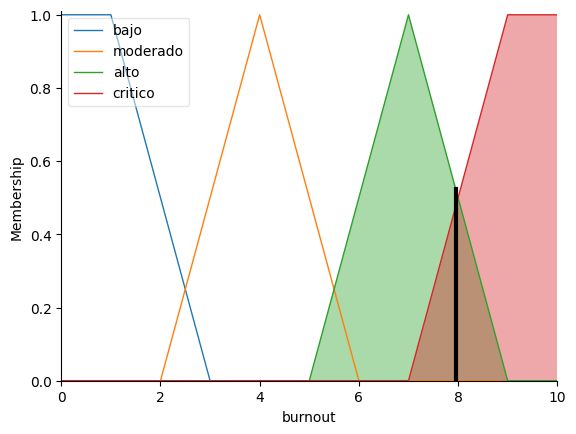

In [36]:
# FUNCIÓN PARA PRUEBA MANUAL

def evaluacion_manual(sim, datos):
  for var, valor in datos.items():
    sim.input[var] = valor
  sim.compute()
  return sim.output['burnout']

#ejmplo prueba manual
print("PRUEBA MANUAL")
datos_prueba = {
    'edad': 22,
    'cantidad_trabajo_pantalla': 12,
    'carga_total': 8,
    'sueno': 3,
    'tiempo_pantalla_estudio': 7,
    'tiempo_pantalla_ocio': 5,
    'apoyo': 3,
    'pausas': 0,
    'agotamiento': 8,
    'energia': 8,
    'agotamiento_emocional': 8,
    'eficacia_personal': 3,
    'desconectar': 8,
    'presion_digital': 8
}

resultado = evaluacion_manual(burnout_sim, datos_prueba)
print(f"Nivel de burnout: {resultado:.2f}/10")
if resultado <=3:
  print(f"Diagnóstico: BAJO - Sin riesgo significativo")
elif resultado <=6:
  print(f"Diagnóstico: MODERADO - Atención recomendada")
elif resultado <=8:
  print(f"Diagnóstico: ALTO - Intervención necesaria")
else:
  print(f"Diagnóstico: CRÍTICO - Intervención urgente")

burnout.view(sim=burnout_sim)

**procesamiento del csv de la encuesta**

In [47]:
# mapeo de respuestas categóricas a valores numéricos
encoding = {
    'edad': {'18–25': 21, '25–35': 30, 'Más de 35': 45},
    'cantidad_trabajo_pantalla': {
        'Baja(<4h)': 3, 'Media(6-8h)': 7, 'Alta': 12, 'Alta(>10h)': 12
    },
    'carga_total': {'Ligera': 2, 'Manejable': 5, 'Abrumadora': 9},
    'sueno': {
        'Insuficiente': 2, 'Pobre': 4, 'Aceptable': 6,
        'Fantástica': 9, 'Fantástica(8-10h)': 9
    },
    'tiempo_pantalla_estudio': {
        'Escaso(<1h)': 1, 'Medio(1-2h)': 2, 'Alto(2-6h)': 4, 'Excesivo(>6h)': 8
    },
    'tiempo_pantalla_ocio': {
        'Escaso(<1h)': 1, 'Medio(1-2h)': 2, 'Alto(2-6h)': 4, 'Excesivo(>6)': 8
    },
    'apoyo': {'Poco': 2, 'Neutro': 5, 'Mucho': 8},
    'pausas': {
        'Ningua': 0, 'Mínimo (1-2)': 1, 'Mínimo (2-4)': 2,
        'Bastantes(2-4)': 3, 'Bastantes(>4)': 5
    },
    'agotamiento': {'Ínfimo': 2, 'Ordinario': 5, 'Elevado': 8},
    'energia': {
        'Nunca': 2, 'Casi nunca': 3, 'A veces': 6, 'Algunas veces': 7
    },
    'agotamiento_emocional': {
        'Escasamente': 2, 'Esporádicamente': 5, 'Frecuentemente': 8
    },
    'eficacia_personal': {
        'Baja': 2, 'Moderada': 5, 'Alta': 7, 'Muy alta': 9
    },
    'desconectar': {
        'Baja difcultad': 2, 'Moderada': 5, 'Alta dicultad': 8
    },
    'presion_digital': {
        'Raramente': 2, 'Ocasionalmente': 5, 'Constantemente': 8
    },
}


col_indices = {
    'edad': 2, 'cantidad_trabajo_pantalla': 3, 'carga_total': 4,
    'sueno': 5, 'tiempo_pantalla_estudio': 6, 'tiempo_pantalla_ocio': 7,
    'apoyo': 8, 'pausas': 9, 'agotamiento': 10, 'energia': 11,
    'agotamiento_emocional': 12, 'eficacia_personal': 13,
    'desconectar': 14, 'presion_digital': 15
}

csv_path = 'encuesta_results.csv'

respuestas = []
with open(csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)
    for row_num, row in enumerate(reader, 1):
        datos = {}
        valido = True
        for var, col_idx in col_indices.items():
            if col_idx >= len(row) or not row[col_idx].strip():
                valido = False
                break
            respuesta = row[col_idx].strip()
            if respuesta in encoding[var]:
                datos[var] = encoding[var][respuesta]
            else:
                valido = False
                break

        if valido:
            respuestas.append((row_num, datos))

print(f"\nPROCESAMIENTO DEL CSV")
print(f"Respuestas válidas: {len(respuestas)} de {row_num}")


PROCESAMIENTO DEL CSV
Respuestas válidas: 52 de 54


# evaluación de los resultados de la encuesta

In [48]:
print("\n=== RESULTADOS DE LA ENCUESTA ===")
print(f"{'#':>3} | {'Burnout':>7} | {'Diagnóstico':<30}")
print("-" * 50)

resultados = []
for num, datos in respuestas:
    try:
        sim = ctrl.ControlSystemSimulation(burnout_ctrl)
        score = evaluacion_manual(sim, datos)
        resultados.append(score)

        if score <= 3:
            diag = "BAJO"
        elif score <= 6:
            diag = "MODERADO"
        elif score <= 8:
            diag = "ALTO"
        else:
            diag = "CRÍTICO"

        print(f"{num:>3} | {score:>7.2f} | {diag:<30}")
    except Exception as e:
        print(f"{num:>3} | {'ERROR':>7} | {str(e)[:30]}")


=== RESULTADOS DE LA ENCUESTA ===
  # | Burnout | Diagnóstico                   
--------------------------------------------------
  1 |    5.29 | MODERADO                      
  2 |    5.50 | MODERADO                      
  3 |    6.52 | ALTO                          
  4 |    6.52 | ALTO                          
  5 |    5.50 | MODERADO                      
  6 |    5.98 | MODERADO                      
  7 |    5.29 | MODERADO                      
  8 |    4.86 | MODERADO                      
  9 |    8.06 | CRÍTICO                       
 10 |    4.00 | MODERADO                      
 11 |    6.52 | ALTO                          
 12 |    6.47 | ALTO                          
 13 |    4.00 | MODERADO                      
 14 |    6.52 | ALTO                          
 15 |    2.95 | BAJO                          
 17 |    6.77 | ALTO                          
 18 |    6.52 | ALTO                          
 19 |    6.70 | ALTO                          
 20 |    6.09 | ALTO 


=== ESTADÍSTICAS ===
Media de burnout: 5.78
Mediana: 5.98
Mínimo: 2.54
Máximo: 8.06
Desv. estándar: 1.14

Distribución:
  Bajo (0-3):     2 (3.8%)
  Moderado (3-6): 26 (50.0%)
  Alto (6-8):     23 (44.2%)
  Crítico (8-10): 1 (1.9%)


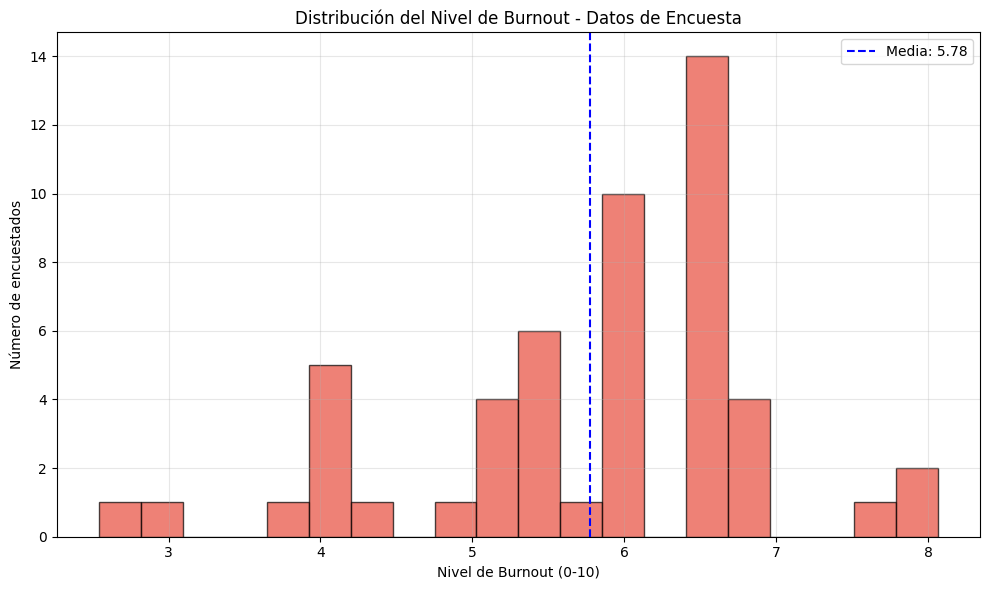

In [49]:
#estadísticas generales
if resultados:
    import matplotlib.pyplot as plt

    print(f"\n=== ESTADÍSTICAS ===")
    print(f"Media de burnout: {np.mean(resultados):.2f}")
    print(f"Mediana: {np.median(resultados):.2f}")
    print(f"Mínimo: {np.min(resultados):.2f}")
    print(f"Máximo: {np.max(resultados):.2f}")
    print(f"Desv. estándar: {np.std(resultados):.2f}")

    bajo = sum(1 for r in resultados if r <= 3)
    moderado = sum(1 for r in resultados if 3 < r <= 6)
    alto = sum(1 for r in resultados if 6 < r <= 8)
    critico = sum(1 for r in resultados if r > 8)

    print(f"\nDistribución:")
    print(f"  Bajo (0-3):     {bajo} ({bajo/len(resultados)*100:.1f}%)")
    print(f"  Moderado (3-6): {moderado} ({moderado/len(resultados)*100:.1f}%)")
    print(f"  Alto (6-8):     {alto} ({alto/len(resultados)*100:.1f}%)")
    print(f"  Crítico (8-10): {critico} ({critico/len(resultados)*100:.1f}%)")

    # Histograma de resultados
    plt.figure(figsize=(10, 6))
    plt.hist(resultados, bins=20, edgecolor='black', alpha=0.7, color='#e74c3c')
    plt.axvline(np.mean(resultados), color='blue', linestyle='--', label=f'Media: {np.mean(resultados):.2f}')
    plt.xlabel('Nivel de Burnout (0-10)')
    plt.ylabel('Número de encuestados')
    plt.title('Distribución del Nivel de Burnout - Datos de Encuesta')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()